# Paper Families as Configurable SILVA Architectures

This notebook checks the package mechanisms used to construct DEQ,
MDEQ, Jacobian-regularized, IGNN, implicit-representation, and
diffusion cases. It is a CPU validation tutorial, not a claim that the
source papers' datasets, schedules, checkpoints, or metrics were run.

All cases share

$$z^\star=f_\theta(z^\star,x).$$

The user selects the state, transition operators, solver, gradient
estimator, dimensions, data, optimizer, and evaluation protocol.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[5]](https://jseluis.github.io/silva-networks/paper/references/#ref-5), [[6]](https://jseluis.github.io/silva-networks/paper/references/#ref-6), [[7]](https://jseluis.github.io/silva-networks/paper/references/#ref-7), [[8]](https://jseluis.github.io/silva-networks/paper/references/#ref-8), [[9]](https://jseluis.github.io/silva-networks/paper/references/#ref-9), [[36]](https://jseluis.github.io/silva-networks/paper/references/#ref-36), [[37]](https://jseluis.github.io/silva-networks/paper/references/#ref-37), [[38]](https://jseluis.github.io/silva-networks/paper/references/#ref-38). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks"), Path("/content/drive/MyDrive/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
from torch import nn

from silva_networks import (
    SILVADEQEngine,
    SILVADiffusionEquilibrium,
    SILVAImplicitGraphNetwork,
    SILVAImplicitNeuralRepresentation,
    SILVAMultiscaleClassifier,
    SILVAMultiscaleSegmenter,
    SILVASequenceDEQ,
    SolverConfig,
    jacobian_regularization_loss,
)

torch.manual_seed(12)
fast = SolverConfig(solver="picard", max_iter=3, alpha=0.5)
exact = SolverConfig(
    solver="picard",
    max_iter=3,
    alpha=0.5,
    backward_mode="implicit",
    backward_solver="gmres",
    backward_max_iter=8,
    backward_tol=1e-5,
    backward_stop_mode="relative",
)

## Sequence DEQ

The transition can be relative-attention Transformer or causal
trellis. Memory, local attention, banded adaptive input and output,
weight/projection tying, dropout, and every solver option are
constructor parameters. Custom transition, embedding, and readout
modules are supported as well.

In [3]:
sequence = SILVASequenceDEQ(
    8,
    vocab_size=24,
    heads=2,
    inner_dim=16,
    memory_length=3,
    local_window=4,
    adaptive_cutoffs=(8, 16),
    adaptive_div_value=2.0,
    embedding_dim=8,
    config=exact,
)
seq = sequence(torch.randint(0, 24, (2, 5)), return_result=True)
targets = torch.randint(0, 24, (2, 5))
sequence.adaptive_loss(seq.state, targets).backward()
print(seq.output.shape, seq.memory.shape, seq.solver_result.solver)
print("normalized probabilities", seq.output.exp().sum(dim=-1))

trellis = SILVASequenceDEQ(
    8,
    input_dim=5,
    output_dim=3,
    mode="trellis",
    tie_embeddings=False,
    config=fast,
)
print("trellis", trellis(torch.randn(2, 5, 5)).shape)

torch.Size([2, 5, 24]) torch.Size([2, 3, 8]) picard
normalized probabilities tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]], grad_fn=<SumBackward1>)
trellis torch.Size([2, 5, 3])


## Multiscale DEQ and Jacobian Regularization

Every resolution is part of one coupled state. Every-to-every
projections and resampling implement cross-scale interaction. The
built-in MDEQ mode uses learned downsampling chains and projected
upsampling; stimulus injection, convolution weight normalization,
and classification/segmentation heads remain selectable.

A paper-selected Jacobian term estimates
$\|J_f(z^\star)\|_F^2$ with Hutchinson probes.

In [4]:
image = torch.randn(1, 3, 8, 8)
classifier = SILVAMultiscaleClassifier(
    3,
    (4, 6),
    3,
    expansion=1.0,
    groups=2,
    weight_norm=True,
    fusion_mode="mdeq",
    injection_mode="highest",
    config=fast,
)
segmenter = SILVAMultiscaleSegmenter(
    3, (4, 6), 2, expansion=1.0, groups=2, config=fast
)
cls = classifier(image, return_result=True)
print("classification", cls.output.shape, [z.shape for z in cls.states])
print("segmentation", segmenter(image).shape)

matrix = nn.Parameter(0.2 * torch.eye(4))
state = torch.randn(2, 4)
transition = lambda z: torch.tanh(z @ matrix)
penalty = jacobian_regularization_loss(transition, state, samples=2, weight=0.01)
print("Jacobian penalty", float(penalty.detach()))

classification torch.Size([1, 3]) [torch.Size([1, 4, 8, 8]), torch.Size([1, 6, 4, 4])]
segmentation torch.Size([1, 2, 8, 8])
Jacobian penalty 0.0029232397209852934


## IGNN, Implicit Representations, and DEQ-DDIM

These applications change the domain-specific transition while
retaining the same equilibrium and gradient contracts.

In [5]:
edges = torch.tensor([[0, 1, 2, 3], [1, 2, 3, 0]])
graph = SILVAImplicitGraphNetwork(3, 5, 2, config=fast)
graph.project_recurrent_norm(0.9)
print("IGNN", graph(torch.randn(4, 3), edges).shape)

coordinates = torch.rand(1, 7, 2, requires_grad=True)
inr = SILVAImplicitNeuralRepresentation(
    2, 6, 1, injection="fourier", activation="tanh", config=fast
)
print("INR", inr(coordinates).shape, inr.coordinate_gradient(coordinates).shape)

class ZeroDenoiser(nn.Module):
    def forward(self, x, timestep):
        del timestep
        return torch.zeros_like(x)

ddim = SILVADiffusionEquilibrium(
    ZeroDenoiser(),
    torch.linspace(0.99, 0.5, 10),
    (9, 6, 3, 0, -1),
    config=SolverConfig(solver="picard", max_iter=6, alpha=1.0),
)
diffusion = ddim(torch.randn(1, 1, 3, 3), return_result=True)
print("DDIM", diffusion.output.shape, diffusion.trajectory.shape)

IGNN torch.Size([4, 2])
INR torch.Size([1, 7, 1]) torch.Size([1, 7, 2])
DDIM torch.Size([1, 1, 3, 3]) torch.Size([5, 1, 1, 3, 3])


## Beyond the Referenced Cases

`SILVADEQEngine` accepts a user transition over one tensor or a
nested tuple/list state. This is the extension point for a new
architecture; no package family registration is required.

In [6]:
stimulus = torch.randn(2, 4)
custom_transition = nn.Sequential(nn.Linear(4, 8), nn.Tanh(), nn.Linear(8, 4))
engine = SILVADEQEngine(fast)
custom = engine(lambda z: 0.2 * custom_transition(z) + stimulus, torch.zeros_like(stimulus))
print("custom equilibrium", custom.shape)

custom equilibrium torch.Size([2, 4])


## Reproduction Boundary

The successful cells establish executable architecture, solver, and
gradient mechanisms. Reproducing a paper's reported numbers still
requires its exact data, preprocessing, training schedule, evaluation,
random-seed policy, and pretrained components.

Cite the SILVA package and the source paper whose architecture or
experimental protocol you instantiate:
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098

## From 12 Paper Family Architectures to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace the Internals of the Generalized Cases

`SILVASequenceDEQ` accepts custom embedding, transition, and readout modules.
`SILVAMultiscaleDEQ` accepts a custom stem or per-scale injection modules and a
complete multiscale transition. `SILVAImplicitGraphNetwork` accepts source,
recurrent, complete-transition, and readout replacements.

```python
sequence = SILVASequenceDEQ(
    dim=width,
    input_dim=input_width,
    output_dim=classes,
    transition_module=my_sequence_transition,
    embedding_module=my_embedding,
    readout_module=my_readout,
)

multiscale = SILVAMultiscaleDEQ(
    in_channels=3,
    channels=(32, 64, 128),
    injection_mode="all",
    injection_modules=my_scale_sources,
    transition_module=my_multiscale_transition,
)
```


In [7]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [8]:
notebook_reproduction_record = {
    "notebook": '12_paper_family_architectures.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '12_paper_family_architectures.ipynb',
 'state': 'the tensor solved to equilibrium',
 'condition': 'the observed input or source tensor',
 'transition': 'the state-preserving transition evaluated by the root solver',
 'invariants': 'shape, device, dtype, finiteness, and differentiability',
 'compact_metric': 'fixed-point residual and task error against a deterministic target',
 'scale_axis': 'state width, batch size, and data volume'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **spatial feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the tensor solved to equilibrium**, and its repeated map,
**the state-preserving transition evaluated by the root solver**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [9]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('spatial feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


spatial feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


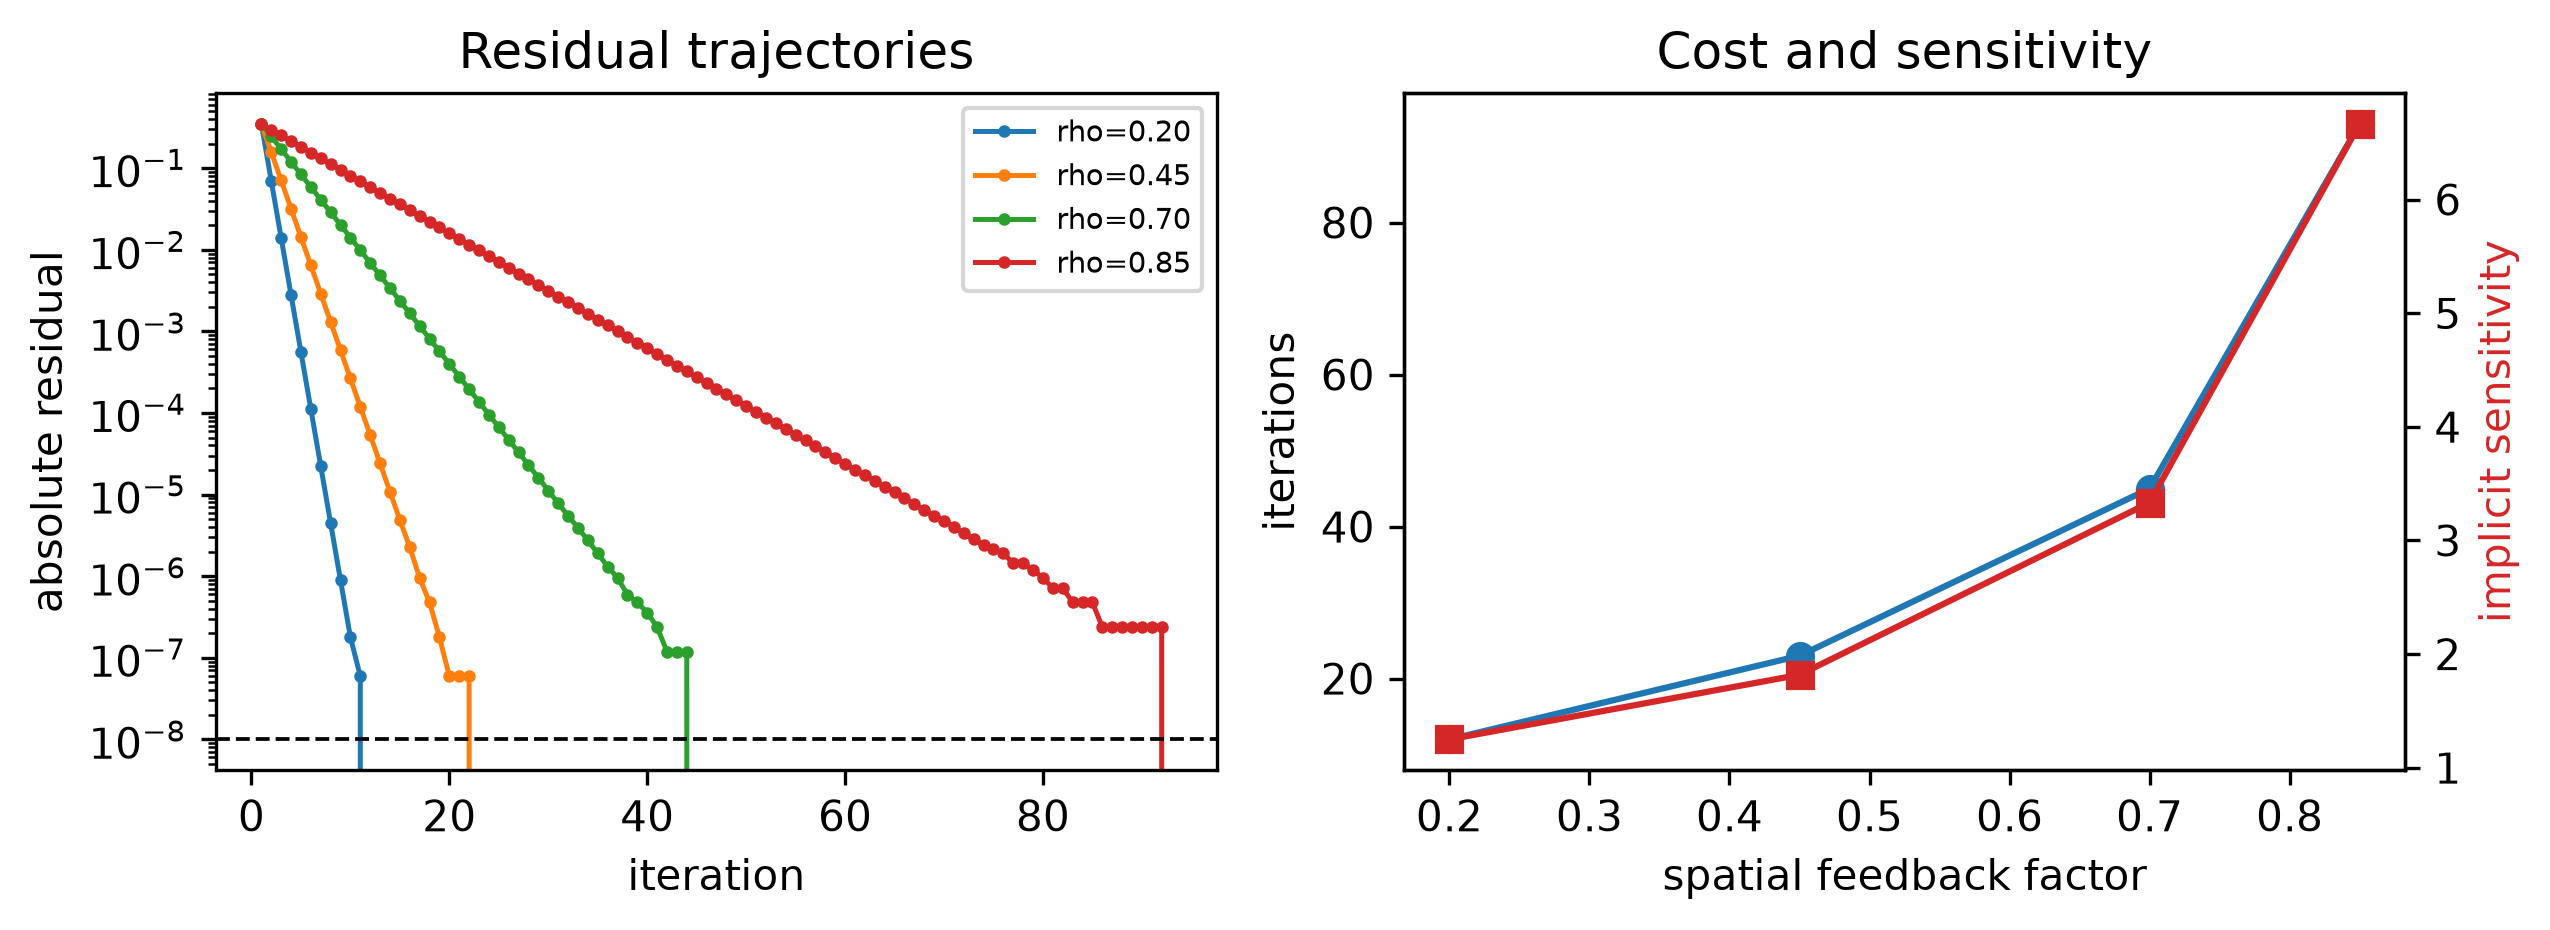

In [10]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('spatial feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the spatial feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | fixed-point residual and task error against a deterministic target |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | shape, device, dtype, finiteness, and differentiability |
| Scale sweep | Change one of state width, batch size, and data volume at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How does each research family connect to SILVA? | [Paper Family Adaptations](https://jseluis.github.io/silva-networks/learn/paper-family-adaptations/) |
| Where are the compact family scripts? | [Paper Family Cases](https://jseluis.github.io/silva-networks/examples/paper-family-cases/) |
| Which generalized case classes are public? | [Generalized Cases API](https://jseluis.github.io/silva-networks/api/cases/) |
